# Emerging Technologies

In [1]:
import numpy as np
import random
import itertools as it
import qiskit
from IPython.display import display
import qiskit_aer as aer

## Introduction
This notebook explores the Deutsch algorithm and its generalisation, the Deutsch–Jozsa algorithm, using Qiskit. These algorithms demonstrate how quantum computation can determine global properties of Boolean functions more efficiently than classical approaches.

The work begins with the single-bit Deutsch problem, where the goal is to determine whether a function is constant or balanced using a quantum circuit. This is then extended to the Deutsch–Jozsa algorithm, which applies the same idea to functions with multiple input bits.

A key component of the implementation is the construction of quantum oracles from classical Boolean functions. In this notebook, a general method is used to convert a classical function $f(x)$ into a quantum circuit that encodes the function using phase kickback. This allows the algorithm to evaluate all possible inputs simultaneously through superposition and extract the result using interference.

The notebook covers:
- Construction of quantum oracles from classical functions
- Building Deutsch and Deutsch-Jozsa circuits
- The role of superposition, phase kickback, and interference
- Simulation and measurement of results using Qiskit
- Testing on constant and balanced functions

The results show how the Deutsch-Jozsa algorithm can determine whether a function is constant or balanced with a single query to the oracle, highlighting a clear advantage over classical computation.

## Problem 1: Generating Random Boolean Functions


In the [Deutsch-Jozsa problem](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm?utm_source=chatgpt.com), we are given access to a Boolean function $f$ as a [black-box (oracle)](https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626). This means we do not know how the function is constructed, we can only provide inputs and observe the outputs. We cannot inspect or analyse the function internally, we can only query it: $f : \{0,1\}^4 \rightarrow \{0,1\}$

We are also given a promise that the function must be either:
* constant: same output returned for every input, or
* balanced: exactly half of the inputs return 'True' and the other half return 'False'.

The task is to decide which one $f$ is, using as few calls (queries) to $f$ as possible.

To simulate this problem classicaly we define `random_constant_balanced()`. This function does not return a Boolean value directly. Instead, it generates and returns another function $f(a,b,c,d)$, which behaves like the unknown oracle.

The function works by first deciding which type of function to create:
* If a constant function is selected, a single output value (True or False) is chosen, and the returned function always outputs that value regardless of the input
* If a balanced function is selected, the code constructs all $2^4=16$ possible input combinations of four Boolean variables. It then randomly selects 8 of these inputs and assigns them the value 'True'. The remaining inputs return 'False'

This all allows us to test a classical decision procedure (and later compare to the [Deutsch-Jozsa quantum algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)) using a function that matches the promised structure IBM discusses.

In [2]:
def random_constant_balanced():
    """
    Generate and return a random 4-input Boolean function.

    The returned function f(a, b, c, d) is guaranteed to be either:
    - constant: all 16 possible inputs give the same output, or
    - balanced: exactly 8 inputs give True and 8 inputs give False.

    This is used to create test functions for the later classical
    and quantum algorithms.
    """
    #Randomly choose whether the function will be constant or balanced
    function_type = random.choice(["constant", "balanced"])
    #Constant case
    if function_type == "constant":
        #Pick one output value and return it for every input
        value = random.choice([False, True])

        def f(a, b, c, d):
            #Return the same value for every input (constant function)
            return value
        #Return the generated function so it can be used as the oracle
        return f

    #Balanced case
    else:
        #Build a list of all 16 possible 4-bit Boolean inputs
        all_inputs = []
        for a in [False, True]:
            for b in [False, True]:
                for c in [False, True]:
                    for d in [False, True]:
                        all_inputs.append((a, b, c, d))
        #Randomly choose 8 inputs that will return True
        true_inputs = random.sample(all_inputs, 8)

        def f(a, b, c, d):
            #Return True only for the selected 8 inputs
            return (a, b, c, d) in true_inputs

        return f

The returned function is defined inside `random_constant_balanced()` and uses this information to determine its output when called. For example:

In [3]:
#Testing f
f = random_constant_balanced()

print(f(False, False, False, False))
print(f(True, False, True, False))
print(f(True, True, True, True))

True
False
True


Here, f behaves exactly like an oracle: we can evaluate it on inputs, but we do not inspect how it was constructed. This mirrors the black-box access assumed in the Deutsch–Jozsa problem.

## Problem 2: Classical Testing for Function Type


Continuing from Problem 1, we now treat the generated function $f$ as a black-box oracle.  Before seeing why the quantum algorithm is powerful, we first need to understand how many oracle queries a classical algorithm needs to decide whether $f$ is constant or balanced.


We are given: $f : \{0,1\}^4 \rightarrow \{0,1\}$

with a promise that $f$ is either:
* constant: same output for every input, or
* balanced: outputs 0 for exactly half the inputs and 1 for the other half.

**Classical algorithm used:**

To determine if $f$ is constant or balanced:
1. Evaluate $f$ on one input and store the output.
2. Evaluate $f$ on the rest of the inputs and compare their outputs to the first.
3. If any output differs, return "balanced" immediately.
4. If 9 outputs in a row match the first, return "constant".

This is correct under the promise: seeing both 0 and 1 cannot happen for a constant function, so it must be balanced.


**Efficiency of solution**

We evaluate `f` on 4-bit input tuples, store the first output, and compare subsequent outputs to it. If we ever see a different output, we can immediately return "balanced", so the algorithm can terminate early. If 9 outputs in a row match the first, we can return "constant", since a balanced 4-input function can only return the same value at most 8 times.

In the worst case, to be 100% certain we must call `f`, $2^{n-1} + 1$ times. This is because a balanced function returns one value on exactly half of its inputs and the other value on the remaining half. Therefore, its possible to see the same output for the first $2^{n-1}$ queries and still not know whether f is constant or balanced. The next query resolves this. For $n = 4$, the maximum number of calls is $2^3 + 1 = 9$.

**References:**

[IBM Quantum Learning notes that a deterministic classical algorithm requires $2^{n-1} + 1$ queries in worst case.](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm?utm_source=chatgpt.com)

In [4]:
def determine_constant_balanced(f):
    """
    Determines whether a 4-input Boolean function f is constant or balanced.

    It evaluates f on input tuples of length 4, stores the first output,
    and compares subsequent outputs to it. If any output differs, the
    function is balanced. If enough identical outputs are seen, it is constant.
    """
    
    #Generator for all 4-bit inputs
    bin_tuples = it.product((False, True), repeat=4)
    #First evaluation
    first_tuple = next(bin_tuples)
    first = f(*first_tuple)
    print(first_tuple, first)

    same_count = 1

    #Loop through remaining inputs
    for x in bin_tuples:
        val = f(*x)
        print(x, val)

        #If we see a different output = balanced
        if val != first:
            return "balanced"

        same_count += 1
        #If we see 9 identical outputs = must be constant
        if same_count == 9:
            return "constant"
    return "constant"

To test the generated oracle function, we first call `random_constant_balanced()` and store the returned function in $f$. Since $f$ is itself a Boolean function of four inputs, we can then evaluate it on different input combinations such as `(False, False, False, False)` or `(True, False, True, False)`.

This allows us to observe how the generated function behaves without inspecting how it was constructed internally. In this way, $f$ is treated exactly like a black-box oracle: we can query it on inputs and observe outputs, but we do not analyse its internal structure.

These simple test calls confirm that the function returned by `random_constant_balanced()` can now be used in the later classical and quantum parts of the notebook.

In [5]:
f = random_constant_balanced()
print(determine_constant_balanced(f))

(False, False, False, False) True
(False, False, False, True) True
(False, False, True, False) True
(False, False, True, True) True
(False, True, False, False) True
(False, True, False, True) True
(False, True, True, False) True
(False, True, True, True) True
(True, False, False, False) True
constant


## Problem 3: Quantum Oracles


In Problem 2, the function was treated classically as a black-box oracle. We now move to the quantum setting, where the same idea is represented as a quantum circuit. 

Deutsch’s algorithm is an early quantum algorithm that shows how quantum computation can outperform classical computation for a specific problem. It uses superposition, meaning a qubit can exist in a combination of the states , $|0⟩$ and $|1⟩$ at the same time before measurement, to analyse a property of a function as a whole rather than checking one input at a time. In the single-input case, there are four possible Boolean functions, and each can be represented in Qiskit by a corresponding quantum oracle.

To represent these four possible one-bit Boolean functions in Qiskit, we define `deutsch_function(case)`, which returns the corresponding 2-qubit oracle circuit for the selected case.

1. This function takes one input `case`, which can be 1, 2, 3 or 4.
- The parameter case labels which of the four possible one-bit Boolean functions is being implemented.


2. If `case` is not 1, 2, 3 or 4, function raises an error preventing invalid choices.

3. `f = QuantamCircuit(2)` creates a quantum circuit with 2 qubits.
In Deutsch’s algorithm, these 2 qubits are usually:
* qubit 0 = input qubit
* qubit 1 = output qubit

At this point the circuit is empty, with no gates yet.

4. If the case is 2 or 3, add a CNOT gate, `f.cx(0,1)` means:
* qubit 0 is the control,
* qubit 1 is the target
So:
* If qubit 0 is 0, nothing happens
* If qubit 0 is 1, qubit 1 flips

This makes the output depend on the input.

5. If the case is 3 or 4, add an X gate to qubit 1.
`f.x(1)` flips qubit 1 regardless of input. So:
* 0 becomes 1
* 1 becomes 0

This either changes the oracle to “always 1” or turns $f(x)$ into $f(x) = ¬x$, depending on whether there was already a CNOT.

**References:**

The code used in this section was adapted from IBM Quantum Learning materials on the Deutsch algorithm.

[IBM Quantum Learning – Deutsch Algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm)


In [6]:
def deutsch_function(case: int):
    """
    Returns oracle circuit for the chosen case.

    Constructs four possible oracle circuits for Deutsch's algorithm. 
    Each case corresponds to one of the four Boolean functions from one bit to one bit: 
    two constant functions and two balanced functions.
    """

    #Validating that the selected case is one of the four valid options
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
    #Creating quantum circuit with 2 qubits: one input qubit and one output qubit
    f = qiskit.QuantumCircuit(2)
    #If the case is 2 or 3, apply CNOT gate
    #Cases 2 and 3 require the output to depend on the input
    if case in [2, 3]:
        f.cx(0, 1)
    #If case is 3 or 4, apply X (NOT) gate
    #Cases 3 and 4 require an additional flip of the output qubit
    if case in [3, 4]:
        f.x(1)
    #Return oracle circuit for chosen case
    return f

### The four oracle cases are therefore

**Case 1: Oracle for $f(x) = 0$** 

The circuit contains no gates, so the output qubit is never flipped. Therefore $f(0) = 0$ and $f(1) = 0$, which means the function is **constant**.

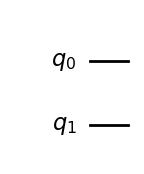

In [7]:
display(deutsch_function(1).draw(output="mpl"))


**Case 2: Oracle for $f(x) = x$** 

This circuit contains a CNOT gate with qubit 0 as the control and qubit 1 as the target. The output qubit flips only when the input qubit is 1, so $f(0) = 0$ and $f(1) = 1$, which means the function is **balanced**.

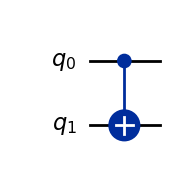

In [8]:
display(deutsch_function(2).draw(output="mpl"))

**Case 3: Oracle for $f(x) = ¬x$**

This circuit contains a CNOT gate followed by an X gate on the output qubit. The CNOT makes the output depend on the input, and the X gate then flips the output regardless of input. This gives $f(0) = 1$ and $f(1) = 0$, which means the function is **balanced**.

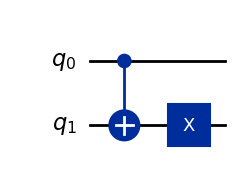

In [9]:
display(deutsch_function(3).draw(output="mpl"))


**Case 4: Oracle for $f(x) = 1$**

This circuit contains only an X gate on the output qubit, so the output is always flipped regardless of the input. Therefore $f(0) = 1$ and $f(1) = 1$, which means the function is **constant**.


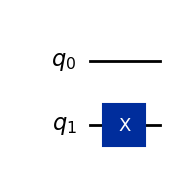

In [10]:
display(deutsch_function(4).draw(output="mpl"))

Therefore, the `deutsch_function` successfully constructs the four quantum oracles required for the single-input version of Deutsch’s algorithm.

## Problem 4: Deutsch's Algorithm with Qiskit


Deutsch’s algorithm solves the single-input version of Deutsch’s problem using a quantum circuit and only one query to the oracle. The goal is to determine whether a Boolean function $f : \{0,1\} \rightarrow \{0,1\}$ is constant or balanced.

In the previous problem, the four possible one-bit Boolean functions were implemented as quantum oracles. In this problem, those oracle circuits are inserted into the full Deutsch circuit so that the function type can be identified from the measurement result.

For a one-bit input, the four possible functions are:

- $f(x) = 0$
- $f(x) = 1$
- $f(x) = x$
- $f(x)=¬x$

The first two are constant and the last two are balanced.

The task of Deutsch’s algorithm is to determine which type the function belongs to by using the oracle only once.

### Structure of Deutsch’s algorithm

The circuit uses two qubits:

- **qubit 0**: the input qubit
- **qubit 1**: the output qubit

and one classical bit to store the final measurement result.

The oracle from Problem 3 is placed in the middle of the circuit. The rest of the circuit prepares the qubits in the correct states, allows the oracle to act on them, and then uses interference (when quantum states combine and affect each other’s amplitudes) to reveal whether the function is constant or balanced.

### Building the Deutsch Circuit

`compile_circuit` constructs the full Deutsch algorithm circuit around a chosen oracle. It does not create a new oracle itself. Instead, it takes one of the oracle circuits from Problem 3 and inserts it into the middle of the algorithm.

In [11]:
def compile_circuit(function: qiskit.QuantumCircuit):
    """
    Builds the full circuit for Deutsch's algorithm using a chosen oracle from Problem 3.
    """

    #1 input qubit, 1 output qubit and 1 classical bit for measurement
    n = function.num_qubits - 1
    qc = qiskit.QuantumCircuit(n + 1, n)

    #Prepare the output qubit in |1>
    qc.x(n)
    #Apply Hadamard gates to both qubits to create superposition
    qc.h(range(n + 1))

    #Inserting oracle from Problem 3
    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    #Applying final Hadamard to the input qubit
    qc.h(range(n))
    #Measuring input qubit
    qc.measure(range(n), range(n))

    return qc

### 1. Initial state and output-qubit preparation


The circuit starts in the state $|00\rangle$. It first applies an X gate to the output qubit, changing the state to $|01\rangle$. This is done so that after a Hadamard gate is applied, the output qubit becomes the state $|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}$.

This means the qubit is in a superposition of 0 and 1, but with a minus sign on the $|1\rangle$ part. That minus sign is important because it allows the oracle to create a **phase change**. A phase change means the state keeps the same basis states, but one part picks up a minus sign, changing how the amplitudes combine later through interference.

This state is used for the second qubit so the oracle’s effect appears as a phase change rather than just an ordinary output bit.

### 2. Putting qubits into superposition

The circuit then applies a Hadamard gate to both qubits.

The Hadamard transforms the basis states as follows: 

$H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}$

$H|1\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}$

So after Hadamard gates: 

the input qubit becomes - $\frac{|0\rangle+|1\rangle}{\sqrt{2}}$

the outbit qubit becomes - $\frac{|0\rangle-|1\rangle}{\sqrt{2}}$

So the full state is $\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)\otimes\left(\frac{|0\rangle-|1\rangle}{\sqrt{2}}\right)$

At this point, the input qubit is in a superposition of both possible inputs, so the oracle can act on both $x=0$ and $x=1$ during a single run of the circuit.



### 3. Inserting the oracle from Problem 3

The oracle is inserted into the circuit using the `compose(...)` operation. This is the point where Problem 4 directly depends on Problem 3.

Each oracle implements the reversible transformation

$U_f|x,y\rangle=|x, y\oplus f(x)\rangle$, 
where:
- $x$ is the input bit,
- $y$ is the output qubit,
- $\oplus$ means XOR

Unlike the classical function in Problem 2, the quantum oracle does not simply return $f(x)$. Instead, it transforms the two-qubit state in a reversible way that allows the function information to influence the amplitudes of the quantum state.


### 4. Phase kickback

Because the second qubit is in the state $\frac{|0\rangle-|1\rangle}{\sqrt{2}}$, the oracle causes the value of $f(x)$ to appear as a phase of the input state. This is known as **phase kickback**.

 After the oracle acts, the input part of the state becomes $\frac{(-1)^{f(0)}|0\rangle+(-1)^{f(1)}|1\rangle}{\sqrt{2}}$

This means the function does not appear as an ordinary output bit. Instead, it changes the sign pattern of the input state. The final Hadamard gate then uses that difference to tell whether the function is constant or balanced.

### 5. Why constant and balanced functions behave differently

If the function is **constant**, then $f(0)$ and $f(1)$ are the same. This means both amplitudes receive the same sign, giving a state equivalent to $\frac{|0\rangle+|1\rangle}{\sqrt{2}}$

If the function is **balanced**, then $f(0)$ and $f(1)$ are different. This means the amplitudes receive opposite signs, giving a state equivalent to $\frac{|0\rangle-|1\rangle}{\sqrt{2}}$

So after the oracle:

- constant functions produce a **plus** superposition
- balanced functions produce a **minus** superposition

The final part of the circuit converts this phase difference into a measurable result.



### 6. Final Hadamard and interference

A final Hadamard gate is applied to the input qubit only.
This uses the identities
$H\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)=|0\rangle$
and 
$H\left(\frac{|0\rangle-|1\rangle}{\sqrt{2}}\right)=|1\rangle$

The oracle creates a phase difference, and the final Hadamard turns that into a normal 0 or 1 result we can measure

- if the function is **constant**, the input qubit becomes $|0\rangle$
- if the function is **balanced**, the input qubit becomes $|1\rangle$

This is the interference step of Deutsch’s algorithm. The amplitudes combine differently for constant and balanced functions, and that difference shows up in the measurement.

### 7. Measurement

Only the input qubit is measured at the end of the circuit.

The measurement result is interpreted as follows:

- **0** means the function is **constant**
- **1** means the function is **balanced**

This is why the algorithm only needs one oracle call. Superposition and interference let the circuit work out whether the function is constant or balanced from one final measurement.

#### Demonstrating use of quantum circuit using oracle 3

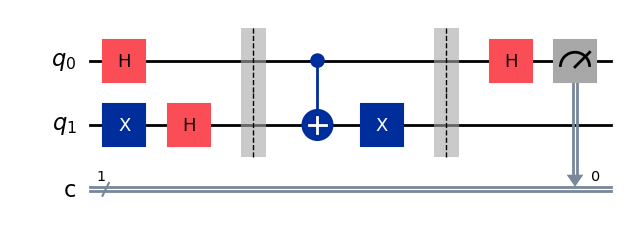

In [12]:
display(compile_circuit(deutsch_function(3)).draw(output="mpl"))

### Running the circuit

`deutsch_algorithm` function runs the Deutsch circuit once on a simulator and interprets the measurement result.

It first builds the full circuit using `compile_circuit(function)`, then simulates one execution of the circuit. If the measurement is `0`, it returns **constant**. Otherwise, it returns **balanced**.

This provides the final algorithmic answer for the chosen oracle.

In [13]:
def deutsch_algorithm(function: qiskit.QuantumCircuit):
    """
    Determine whether a one-bit function is constant or balanced using a quantum oracle.

    The function builds the full Deutsch circuit using compile_circuit(function),
    then runs it once on a simulator.

    The measurement result is interpreted as:
      0 = constant
      1 = balanced
    """

    #Building the full Deutsch circuit using the selected oracle
    qc = compile_circuit(function)

    #Run circuit once on simulator
    result = aer.AerSimulator().run(qc, shots=1, memory=True).result()
    #Read measurement result 
    measurements = result.get_memory()
    #Interpret result: 0 = constant, 1 = balanced
    if measurements[0] == "0":
        return "constant"
    return "balanced"

### Testing the algorithm on the four oracle cases

We can now run Deutsch’s algorithm on each of the four oracle circuits from Problem 3.

The expected outcomes are:

- Case 1: $f(x)=0$ - constant
- Case 2: $f(x)=x$ - balanced
- Case 3: $f(x)=¬x$ - balanced
- Case 4: $f(x)=1$ - constant

If the circuit is correct, the measured result should agree with these classifications.

In [14]:
f = deutsch_function(1)
display(deutsch_algorithm(f))

'constant'

In [15]:
f = deutsch_function(2)
display(deutsch_algorithm(f))

'balanced'

In [16]:
f = deutsch_function(3)
display(deutsch_algorithm(f))

'balanced'

In [17]:
f = deutsch_function(4)
display(deutsch_algorithm(f))

'constant'

The results match the expected classifications for all four oracle cases, showing that the circuit works correctly.

Deutsch’s algorithm was the first algorithm that demonstrated a quantum advantage: specifically a reduction in query complexity compared to the classical case.

**References and attribution:**

The code used in this section was adapted from IBM Quantum Learning materials on the Deutsch algorithm.

- [IBM Quantum Learning – Deutsch Algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm)

The conceptual explanation of Deutsch’s algorithm in this section was informed by IBM Quantum Learning materials on Deutsch Algorithm referenced above, IBM Deutsch-Jozsa Algorithm walkthrough by Dr. Katie McCormick and University of Cambridge quantum computing lecture notes.

- [University of Cambridge – Quantum Computing Lecture 7](https://www.cl.cam.ac.uk/teaching/1920/QuantComp/Quantum_Computing_Lecture_7.pdf)

- [IBM Quantum Learning - Deutsch-Jozsa Algorithm walkthrough video by Dr. Kate McCormick](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)

Conceptual explanation of interference was informed by University of Connecticut learning materials
- [University of Connecticut - Constructive and Destructive Interference](https://www.phys.uconn.edu/~gibson/Notes/Section5_2/Sec5_2.htm)

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm


In this problem, the Deutsch algorithm is extended to the Deutsch–Jozsa algorithm, which applies to Boolean functions of the form $f : \{0,1\}^n \rightarrow \{0,1\}$

with the promise that the function is either **constant** or **balanced**.

The Deutsch–Jozsa algorithm determines which type of function is given using a single evaluation of the oracle, whereas a classical algorithm may require multiple evaluations.


### Oracle encoding

The function `function_to_oracle(f, n=4)` constructs a quantum oracle from a classical four-input Boolean function, as introduced in Problem 1.

Rather than selecting from predefined cases, this approach starts with a classical function $f(a,b,c,d)$ and converts it into a quantum circuit that implements: $U_f |x,y\rangle = |x, y \oplus f(x)\rangle$

The oracle is built by checking each possible 4-bit input. For every input where the function returns 'True', the circuit flips the output qubit for that input pattern. For inputs where the function returns 'False', no action is taken.

Because the output qubit is prepared in the state $|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$ the function value is encoded as a phase: $(-1)^{f(x)}$

This ensures the oracle does not change the computational basis states directly, but instead encodes information in their relative phases, which can later be extracted through interference.

This is the phase kickback effect discussed in Problem 4.

In [18]:
def function_to_oracle(f, n=4):
    """
    Convert a classical Boolean function into a Deutsch-Jozsa oracle circuit.

    The function f is assumed to take n Boolean inputs and return either
    True or False. The returned quantum circuit implements the oracle:

        |x>|y> -> |x>|y XOR f(x)|

    For each input x where f(x) = 1 (True), the circuit flips the output qubit using a multi-controlled operation.
    For inputs where f(x) is False, the circuit does nothing.
    """
    #Create a quantum circuit with n input qubits and 1 output qubit
    qc = qiskit.QuantumCircuit(n + 1)

    #Loop through all possible n-bit inputs
    for x in range(2**n):
        #Convert the integer x into an n-bit binary string
        bits = format(x, f"0{n}b")

        #Convert the bitstring into Boolean inputs for f
        #"0" becomes False and "1" becomes True
        inputs = tuple(bit == "1" for bit in bits)

        #Only build an oracle action for inputs where f(x) = True
        if f(*inputs):
            #For any input bit that is 0, apply an X gate first
            #This changes the required input pattern into all 1s,
            #so that the multi-controlled X can detect it
            for i, bit in enumerate(bits):
                if bit == "0":
                    qc.x(i)

            #Apply a multi-controlled X gate to the output qubit
            #This flips the output qubit only when all input qubits are 1
            qc.mcx(list(range(n)), n)

            #Undo the earlier X gates so the input qubits are restored
            for i, bit in enumerate(bits):
                if bit == "0":
                    qc.x(i)

    #Return the completed oracle circuit
    return qc

### Circuit construction

The Deutsch–Jozsa circuit is constructed as follows:

1. Prepare the output qubit in the state $|1\rangle$
2. Apply Hadamard gates to all qubits
3. Apply the oracle $U_f$
4. Apply Hadamard gates to the input qubits
5. Measure the input qubits

If the result is all zeros, the function is constant. Otherwise, it is balanced.

In [19]:
def compile_circuit(function):
    """
    Builds the full Deutsch-Jozsa circuit using a classical 4-input Boolean function.
    """

    #Set number of input qubits
    n = 4
    #Convert the classical function into a quantum oracle circuit
    oracle = function_to_oracle(function, n)
    #Create a circuit with 4 input qubits, 1 output qubit, and 4 classical bits
    qc = qiskit.QuantumCircuit(n + 1, n)
    #Prepare the output qubit in |1> state
    qc.x(n)
    #Apply Hadamard gates to all qubits to create superposition
    qc.h(range(n + 1))
    #Insert the oracle into circuit
    qc.compose(oracle, inplace=True)
    #Applying final Hadamard to the input qubits only
    qc.h(range(n))
    #Measuring input qubits
    qc.measure(range(n), range(n))
    #Return the completed Deutsch-Jozsa circuit
    return qc

### Interference
After the oracle, the phase of each input state depends on $f(x)$.

If the function is constant, all input states pick up the same phase. If the function is balanced, half of the input states pick up the opposite phase.

The final Hadamard gates then recombine the amplitudes of these states. When the phases match, the amplitudes add together. When the phases are opposite, they cancel out. This interference pattern determines the measurement result.

For a constant function, the amplitudes add toward the all-zero state. For a balanced function, they cancel at the all-zero state, so a non-zero result is measured instead.

### Running the Deutsch–Jozsa algorithm

The `dj_algorithm(function)` function executes the completed circuit and returns the measurement result.

The circuit is first constructed using `compile_circuit(function)`, then run once on a simulator. The resulting bitstring is used to classify the function.

If any measured bit is 1, the function is classified as balanced. If all bits are 0, the function is classified as constant.

### Measurement

Only the input qubits are measured at the end of the circuit.

The measurement outcome reflects the interference pattern created by the oracle and the final Hadamard gates. For constant functions, the amplitudes reinforce the all-zero state. For balanced functions, destructive interference prevents the all-zero outcome.

This allows the function type to be determined with a single oracle call.

In [20]:
def dj_algorithm(function: qiskit.QuantumCircuit):
    """
    Determines whether a Boolean function is constant or balanced using
    the Deutsch–Jozsa algorithm.

    The function builds the full circuit using compile_circuit(function),
    runs it once on a simulator, and interprets the measurement result.

    If any measured bit is 1, the function is balanced.
    If all measured bits are 0, the function is constant.
    """

    #Build the full Deutsch–Jozsa circuit using the given oracle
    qc = compile_circuit(function)
    #Run the circuit once on the simulator
    result = aer.AerSimulator().run(qc, shots=1, memory=True).result()
    #Get the measurement result as a bitstring
    measurements = result.get_memory()
    #If any bit is 1, function = balanced
    if "1" in measurements[0]:
        return "balanced"
    #If all bits are 0, function = constant
    return "constant"

### Classical functions used

The following classical four-bit functions are used:

- $f(a,b,c,d) = 0$ - constant
- $f(a,b,c,d) = 1$ - constant
- $f(a,b,c,d) = a$ - balanced
- $f(a,b,c,d) = a \oplus b \oplus c \oplus d$ - balanced

These classical functions are converted into quantum oracle circuits using `function_to_oracle`, allowing the Deutsch–Jozsa algorithm to evaluate them.

In [21]:
def f_const_0(a, b, c, d):
    return False

def f_const_1(a, b, c, d):
    return True

def f_balanced_1(a, b, c, d):
    return a

def f_balanced_2(a, b, c, d):
    return a ^ b ^ c ^ d

### Testing the algorithm on the required four-bit functions
To match the requirements of Problem 5, the Deutsch–Jozsa algorithm is tested on four-bit functions only.

The following cases are used:
- $f(a,b,c,d) = 0$ - constant
- $f(a,b,c,d) = 1$ - constant
- $f(a,b,c,d) = a$ - balanced
- $f(a,b,c,d) = a \oplus b \oplus c \oplus d$ - balanced

If the circuit is correct, Cases 1 and 2 should return constant, while Cases 3 and 4 should return balanced.

f(a,b,c,d)=0
Expected: constant
Measured: constant


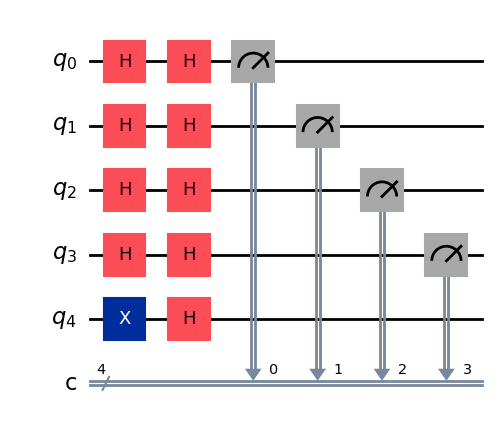

f(a,b,c,d)=1
Expected: constant
Measured: constant


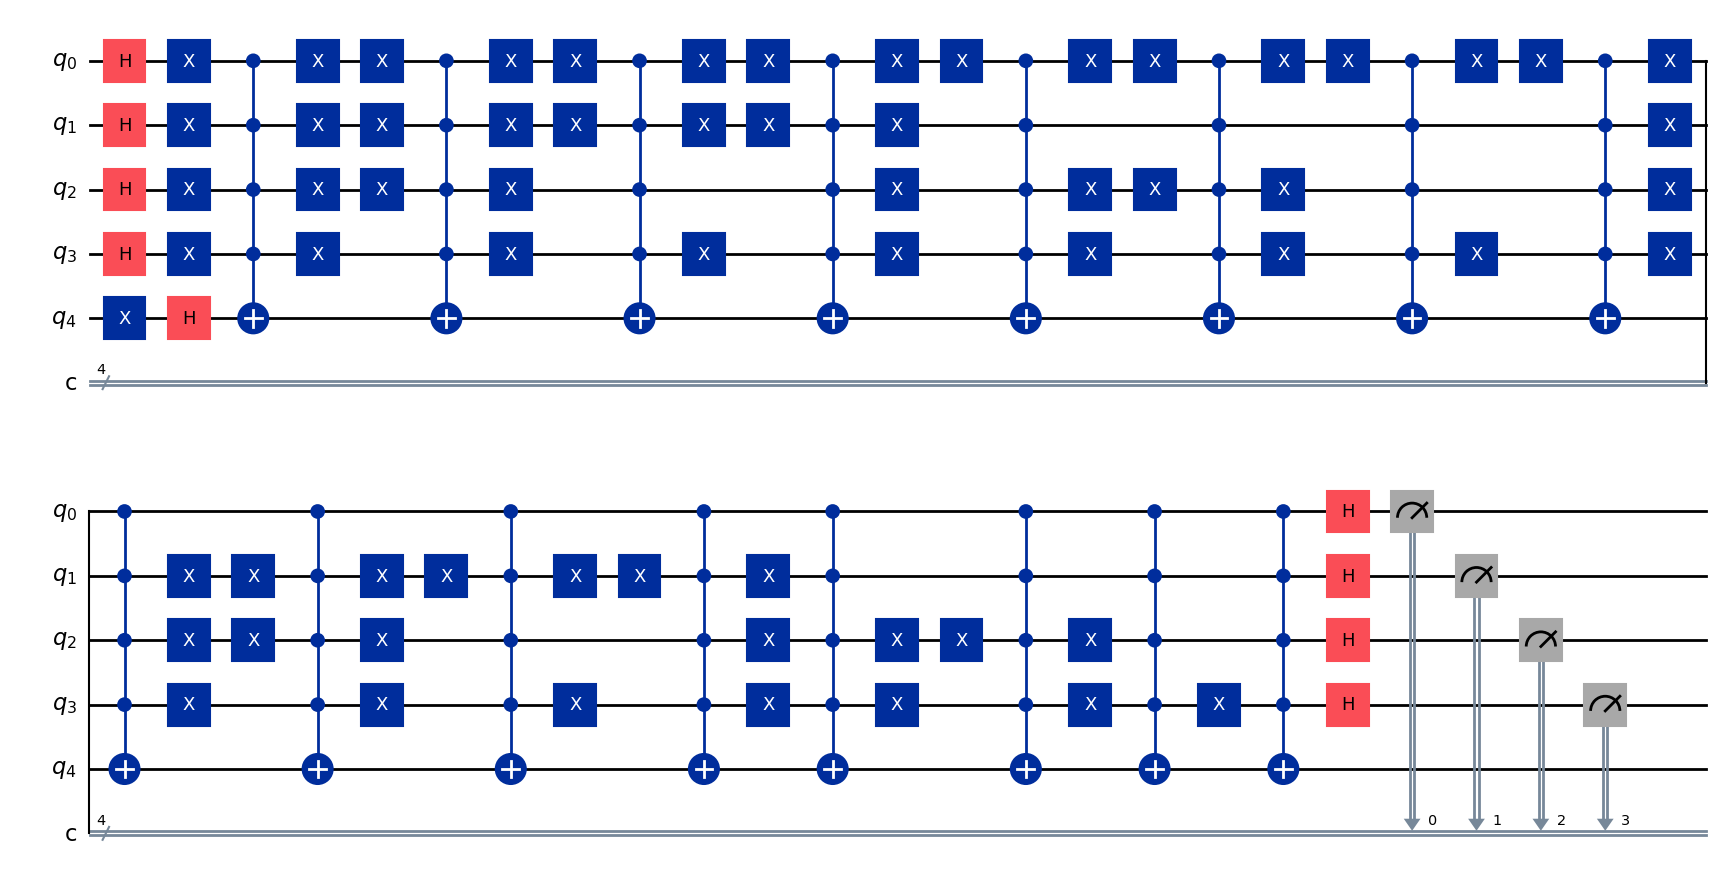

f(a,b,c,d)=a
Expected: balanced
Measured: balanced


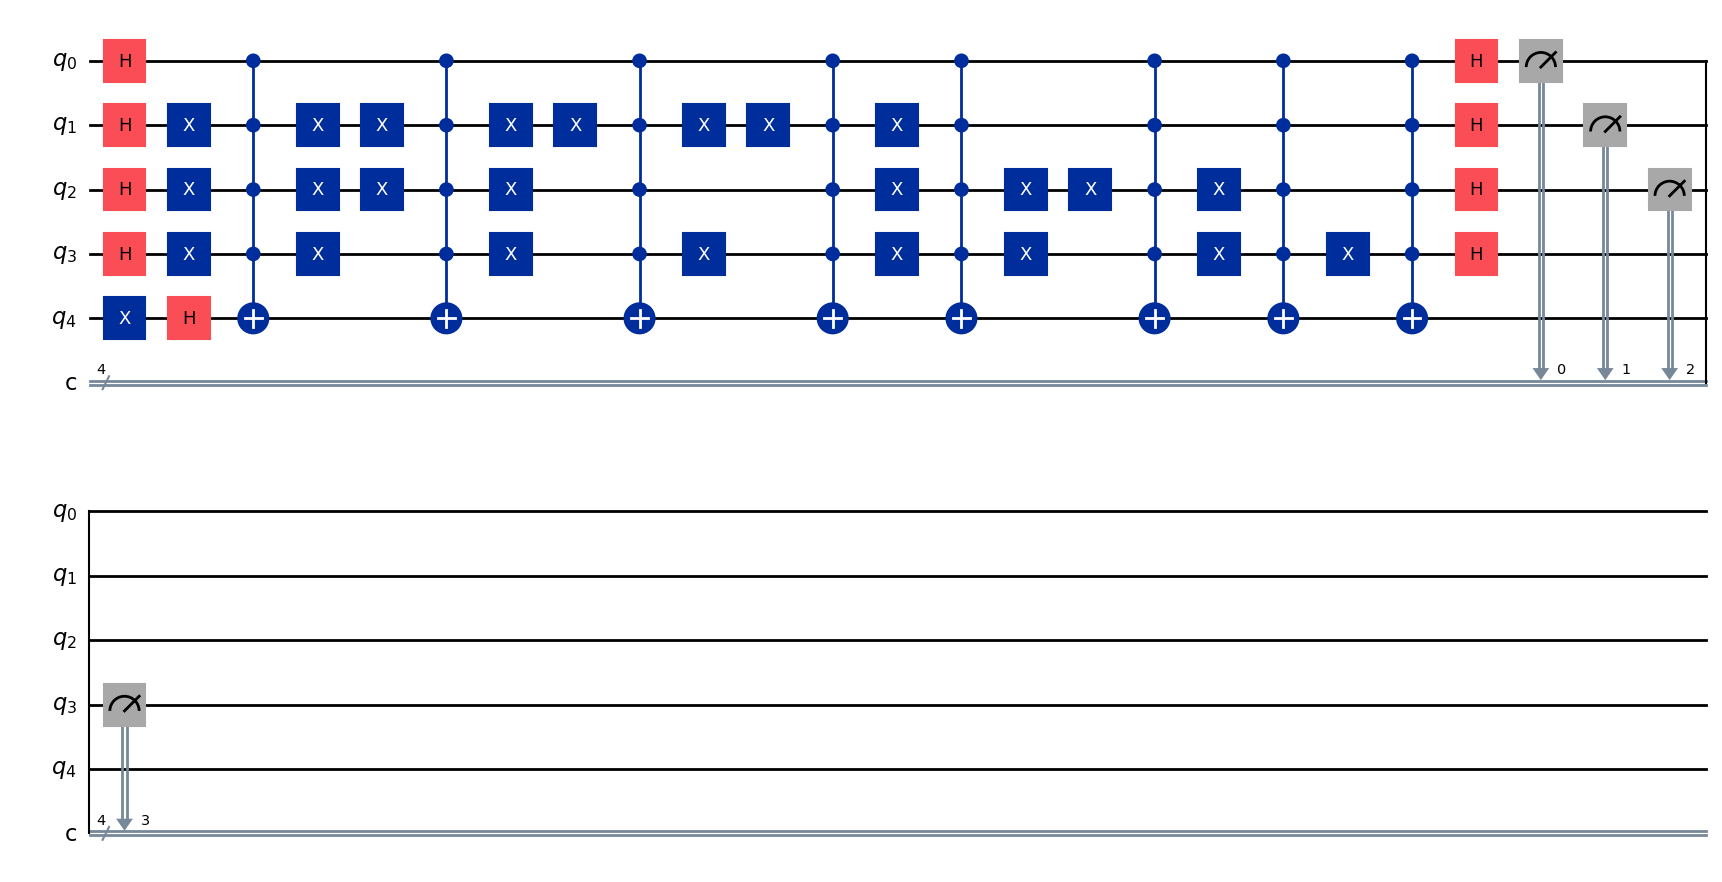

f(a,b,c,d)=a⊕b⊕c⊕d
Expected: balanced
Measured: balanced


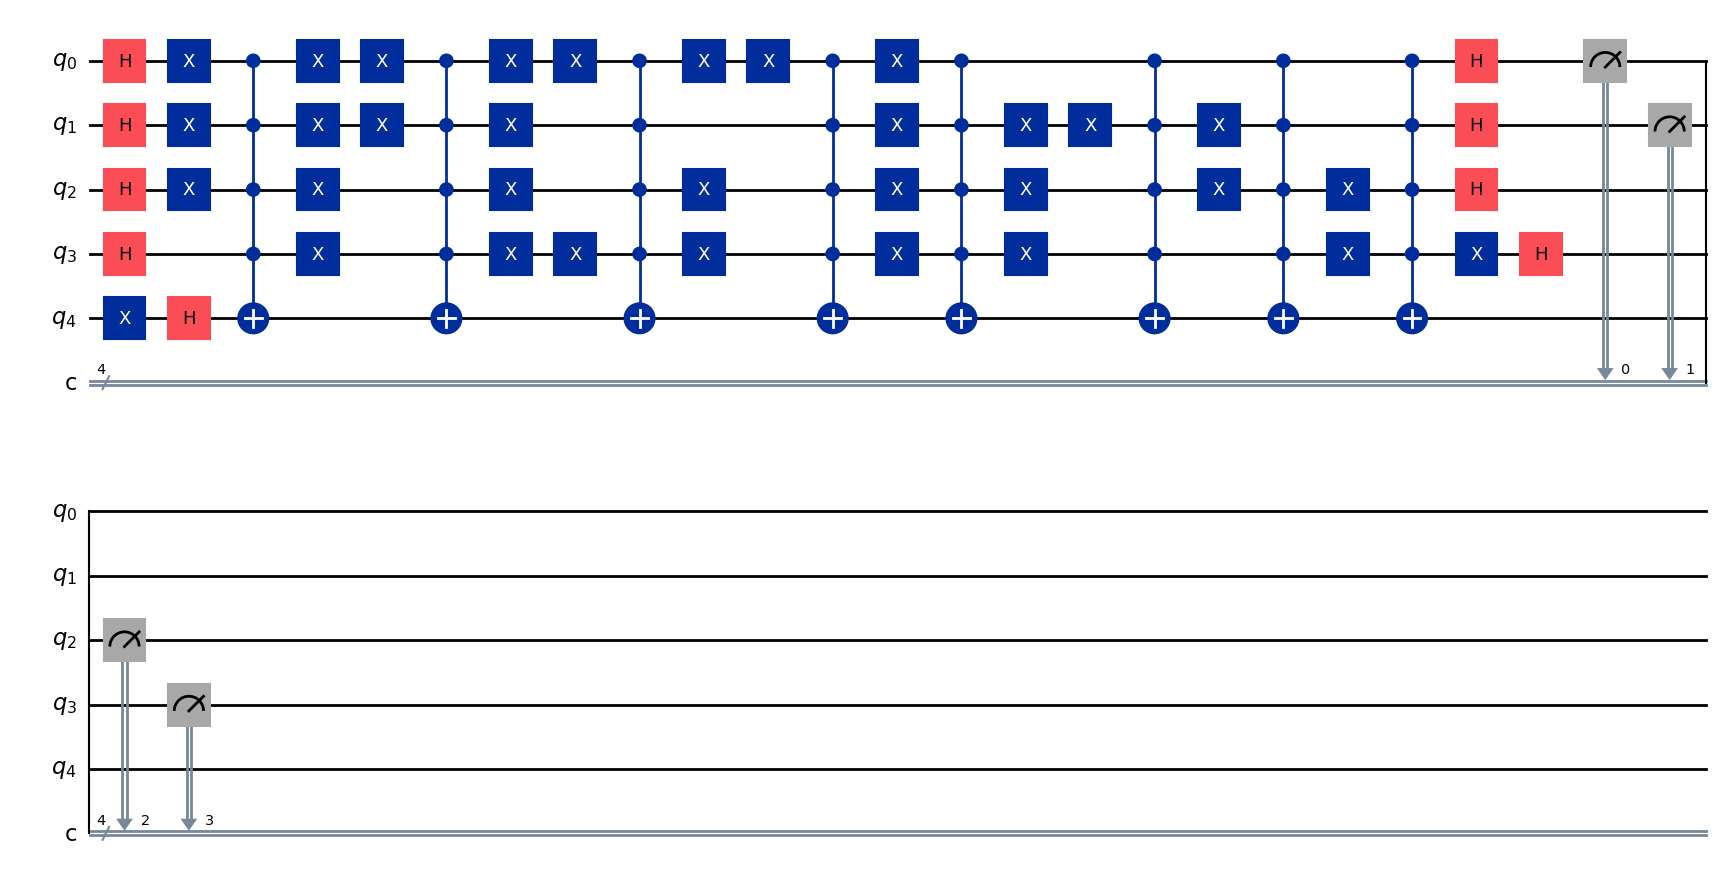

In [22]:
functions = [
    ("f(a,b,c,d)=0", f_const_0, "constant"),
    ("f(a,b,c,d)=1", f_const_1, "constant"),
    ("f(a,b,c,d)=a", f_balanced_1, "balanced"),
    ("f(a,b,c,d)=a⊕b⊕c⊕d", f_balanced_2, "balanced"),
]

for name, f, expected in functions:
    result = dj_algorithm(f)

    print(name)
    print("Expected:", expected)
    print("Measured:", result)

    display(compile_circuit(f).draw(output="mpl"))

**References and attribution:**

The code used in this section was adapted from IBM Quantum Learning materials on the Deutsch algorithm.
- [IBM Quantum Learning - Deutsch-Josza algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm)

Conceptual explanation of interference was informed by University of Connecticut learning materials
- [University of Connecticut - Constructive and Destructive Interference](https://www.phys.uconn.edu/~gibson/Notes/Section5_2/Sec5_2.htm)

The circuit correctly classified all test functions as constant or balanced using a single evaluation.

This demonstrates the advantage of the Deutsch–Jozsa algorithm over classical approaches, which would require multiple evaluations. While the oracle is constructed using a brute-force method, the result highlights how quantum superposition and interference enable more efficient problem solving.

## Conclusion

This notebook demonstrated the implementation of the Deutsch and Deutsch–Jozsa algorithms using Qiskit, highlighting how quantum computation can determine global properties of Boolean functions more efficiently than classical methods.

The Deutsch algorithm showed that, for a single-bit function, it is possible to determine whether the function is constant or balanced using a single evaluation of the oracle. This idea was then extended in the Deutsch–Jozsa algorithm to functions with multiple input bits, where the same classification can still be achieved with only one oracle query, regardless of the number of inputs.

A key contribution of this work was the construction of quantum oracles from classical Boolean functions. By converting classical functions into quantum circuits using controlled operations, the function values were encoded as phases through the phase kickback effect. This allowed the quantum circuit to evaluate all possible inputs simultaneously via superposition.

The final Hadamard transformations played a crucial role in converting these phase differences into measurable outcomes through interference. As a result, constant functions produced an all-zero measurement, while balanced functions produced a non-zero result, enabling clear classification.

The results obtained from testing confirmed that the implementation behaves as expected for both constant and balanced functions. Overall, this work demonstrates the fundamental advantage of quantum algorithms in solving specific problems more efficiently than classical approaches, as well as providing insight into key quantum concepts such as superposition, phase encoding, and interference.